# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
image = plt.imread('data/ejer_kmeans.png')
image.shape

(764, 1499, 3)

Muestra la imagen para ver que se ha cargado bien

In [3]:
image

array([[[0.5686275 , 0.5803922 , 0.61960787],
        [0.5529412 , 0.5647059 , 0.6039216 ],
        [0.54901963, 0.5686275 , 0.6039216 ],
        ...,
        [0.7529412 , 0.7882353 , 0.827451  ],
        [0.74509805, 0.78039217, 0.8235294 ],
        [0.1254902 , 0.12941177, 0.14117648]],

       [[0.5647059 , 0.5764706 , 0.6156863 ],
        [0.54901963, 0.5647059 , 0.6       ],
        [0.54901963, 0.5686275 , 0.6039216 ],
        ...,
        [0.7529412 , 0.7882353 , 0.83137256],
        [0.7490196 , 0.78431374, 0.8235294 ],
        [0.1254902 , 0.12941177, 0.14117648]],

       [[0.5647059 , 0.5764706 , 0.6156863 ],
        [0.54901963, 0.5647059 , 0.6       ],
        [0.54901963, 0.5686275 , 0.6039216 ],
        ...,
        [0.7529412 , 0.7921569 , 0.8352941 ],
        [0.7529412 , 0.7921569 , 0.83137256],
        [0.1254902 , 0.12941177, 0.14117648]],

       ...,

       [[0.26666668, 0.28627452, 0.29411766],
        [0.26666668, 0.28627452, 0.29803923],
        [0.26666668, 0

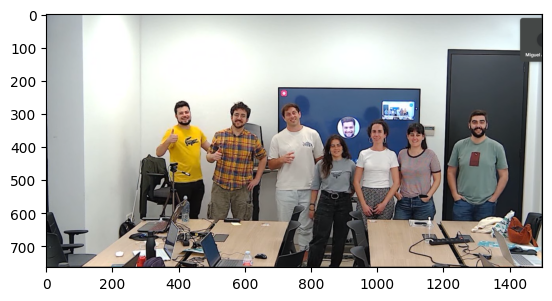

In [ ]:
# Muestra una imagen o una matriz de datos como una imagen 2D.
# En el contexto de datos, se usa habitualmente para visualizar matrices de confusión,
# mapas de calor (heatmaps) o la intensidad de características tras el procesamiento.
plt.imshow(image)


#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [ ]:
# Aplana la imagen para convertirla en una lista de píxeles.
# reshape(-1, 3) transforma la matriz de la imagen (alto, ancho, canales RGB) 
# en una matriz de N filas y 3 columnas (R, G, B). 
# El -1 le dice a NumPy que calcule automáticamente el número de filas necesarias.
X = image.reshape(-1, 3)

# Imprime la nueva dimensión del array. 
# El resultado será (Total_de_Píxeles, 3).
X.shape


(1145236, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [ ]:
# Define la cantidad de colores (clusters) a extraer de la imagen.
k = 10

# Entrena el modelo KMeans para agrupar todos los píxeles de la imagen en 10 colores dominantes.
# n_init=10: Realiza 10 inicializaciones diferentes para encontrar el mejor resultado.
# random_state=10: Garantiza que la selección de colores sea siempre la misma al ejecutarlo.
kmeans = KMeans(n_clusters=k, n_init=10, random_state=10).fit(X)


#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [ ]:
# Recupera las etiquetas asignadas a cada píxel de la imagen.
# Cada valor (de 0 a 9) representa a cuál de los 10 colores dominantes 
# (centroides) pertenece cada píxel individual.
kmeans.labels_


array([4, 4, 4, ..., 0, 0, 0], shape=(1145236,), dtype=int32)

In [ ]:
# Devuelve las dimensiones del array de etiquetas.
# El valor coincidirá con el número total de píxeles (filas) que calculamos 
# anteriormente en X.shape, confirmando que cada píxel tiene asignado un grupo.
kmeans.labels_.shape


(1145236,)

In [ ]:
# Devuelve las coordenadas de los centros de cada uno de los 10 clusters.
# En este contexto, representan los 10 colores promedio (en formato RGB) 
# que el algoritmo ha identificado como los más representativos de la imagen.
kmeans.cluster_centers_


array([[0.09676617, 0.0903998 , 0.09810123],
       [0.7680578 , 0.7733512 , 0.758853  ],
       [0.47438282, 0.3391362 , 0.27370784],
       [0.9695931 , 0.9853263 , 0.97038066],
       [0.54311395, 0.50112164, 0.47960728],
       [0.27042845, 0.3452991 , 0.45578253],
       [0.8734574 , 0.8923224 , 0.8700614 ],
       [0.79676235, 0.6126774 , 0.10117215],
       [0.70817953, 0.6720548 , 0.63220614],
       [0.2377859 , 0.23678187, 0.24834025]], dtype=float32)

In [ ]:
# Crea la imagen segmentada sustituyendo cada píxel original por el color 
# de su centroide correspondiente.
# Utiliza las etiquetas (labels_) como índices para mapear cada píxel 
# al valor RGB de su centro de cluster (cluster_centers_).
segmented_img = kmeans.cluster_centers_[kmeans.labels_]


In [ ]:
# Devuelve las dimensiones del array resultante tras la asignación de colores.
# Confirmará que tienes el mismo número de píxeles que la imagen aplanada (N),
# manteniendo las 3 columnas para los canales de color RGB.
kmeans.cluster_centers_[kmeans.labels_].shape


(1145236, 3)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [ ]:
# Devuelve las dimensiones originales de la imagen (alto, ancho, canales).
# Esta información es crucial para poder reconstruir la imagen segmentada 
# y pasar de una lista plana de píxeles a su forma visual original.
image.shape


(764, 1499, 3)

In [ ]:
# Cambia la forma del array 'segmented_img' (que estaba plano) para que coincida 
# exactamente con las dimensiones de la imagen original (alto, ancho, canales RGB).
# Esto organiza los píxeles procesados en su posición espacial correcta.
segmented_img = segmented_img.reshape(image.shape)


#### 7. Muestra y guarda en tu ordenador la imagen resultante

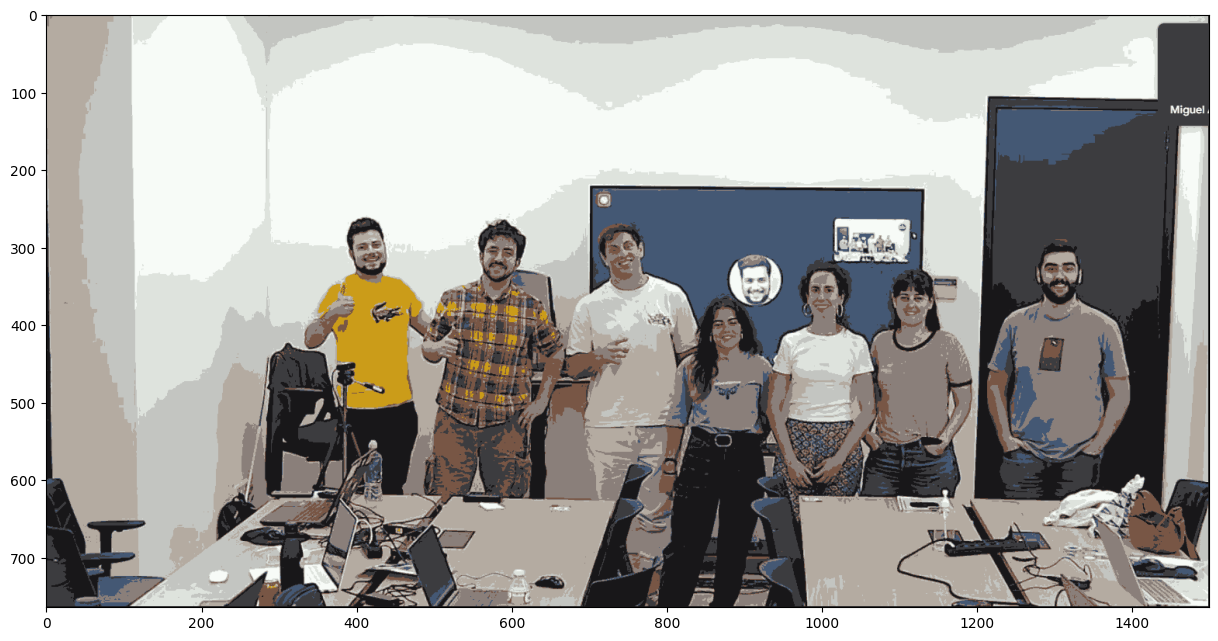

In [ ]:
# Crea una figura con un tamaño de 15x15 pulgadas para asegurar una visualización clara y grande.
fig = plt.figure(figsize=(15,15))

# Muestra la imagen segmentada (cuantizada a 10 colores) en la figura creada.
plt.imshow(segmented_img)


In [ ]:
# Guarda la figura actual en el disco como un archivo de imagen.
# Se almacena en la ruta 'data/' con el nombre 'kmeans_1_output.png'.
# El formato se infiere automáticamente de la extensión del archivo.
fig.savefig("data/kmeans_1_output.png")


#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [ ]:
# Define una función para automatizar el proceso de segmentación de colores en una imagen.
def cluster_colors(image, n_colores, save=False):
    # Lee el archivo de imagen y lo carga como un array numérico.
    image = plt.imread(image)
    
    # Aplana la imagen a una matriz de píxeles (filas) y 3 canales RGB (columnas).
    X = image.reshape(-1,3)
    
    # Entrena el modelo KMeans para encontrar el número de colores principales especificado.
    kmeans = KMeans(n_clusters=n_colores).fit(X)
    
    # Reasigna a cada píxel el color de su centroide (color promedio del grupo).
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    
    # Crea una figura de gran tamaño y muestra la imagen reconstruida con su forma original.
    fig = plt.figure(figsize=(15,15))
    plt.imshow(segmented_img.reshape(image.shape))

    # Si el parámetro 'save' es True, guarda el resultado como "mi_imagen.png".
    if save:
        fig.savefig("mi_imagen.png")


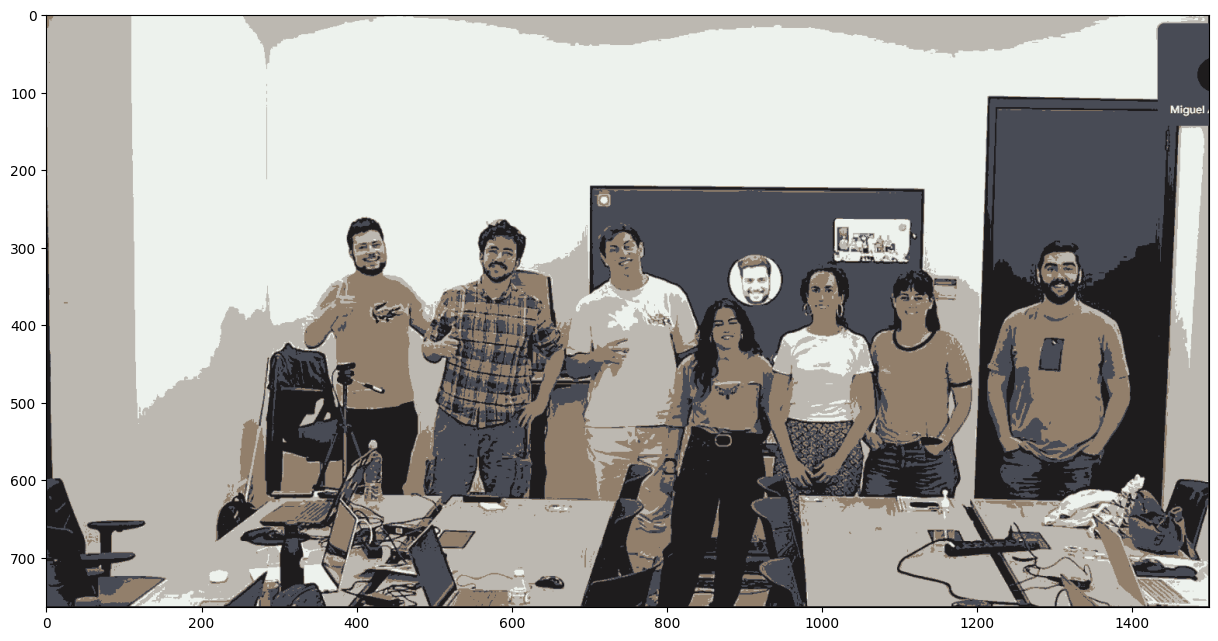

In [ ]:
# Ejecuta la función personalizada para procesar la imagen 'data/ejer_kmeans.png'.
# El algoritmo KMeans agrupará todos los colores de la imagen en solo 5 colores dominantes.
# El resultado se mostrará en pantalla en una figura de 15x15 sin guardarse en disco.
cluster_colors('data/ejer_kmeans.png', 5)
